# BANA212 Final Project: A24 Box Office Analysis 
Team 10A: Claudia Garcia, Nathacia N, Ernesto Mata, Qitong Ou, Tony Liang

## Notebook Roadmap

1. Import packages and load data  
2. Clean and prepare A24 and IMDb datasets  
3. Build modeling dataset (log transforms, genre dummies, A24 flag)  
4. Exploratory data analysis (budgets, ratings, genres, scatterplots)  
5. Linear regression and random forest models  
6. Cross-validation and robustness checks  
7. Key takeaways


## Importing packages and Dataset

In [1]:
# importing packages
import pandas as pd
import numpy as np

# text cleaning packages
import re
import ast

# visualization packages
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning packages: linear regression, random forest, model fit, etc.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# importing a24 movies list
a24 = pd.read_csv("A24_flag.csv")

In [3]:
# importing imdb movies dataset
imdb_df = pd.read_csv("imdb_movies.csv", low_memory = False)

## Data Cleaning and Preparation

In this section, we:
- remove invalid or placeholder revenue values  
- drop rows with zero budget or revenue  
- standardize titles for matching with the A24 list  

In [4]:
# clean title function

def clean_title(title):
    if pd.isna(title):
        return ""
    title = title.lower()                          # lowercase
    title = re.sub(r"[^a-z0-9 ]", " ", title)      # keep only letters, numbers, spaces
    title = re.sub(r"\s+", " ", title)             # collapse multiple spaces
    return title.strip()

### A24 Dataset Cleaning

In [5]:
# a24 data cleaning
a24.head()
a24.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   movie name    182 non-null    object
 1   release year  182 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 3.0+ KB


In [6]:
#dropping exact duplicates
a24 = a24.drop_duplicates()
a24.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   movie name    182 non-null    object
 1   release year  182 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 3.0+ KB


In [7]:
#  renaming variables

a24 = a24.rename(columns={
    'movie name': 'movie_name',
    'release year': 'release_year'
})

In [8]:
# clean titles
a24['title_clean'] = a24['movie_name'].apply(clean_title)

In [9]:
a24.head()

,movie_name,release_year,title_clean
0,A Glimpse Inside the Mind of Charles Swan III,2013,a glimpse inside the mind of charles swan iii
1,Ginger & Rosa,2013,ginger rosa
2,Spring Breakers,2013,spring breakers
3,The Bling Ring,2013,the bling ring
4,The Spectacular Now,2013,the spectacular now


### IMDB Dataset Cleaning

In [10]:
imdb_df.head()
imdb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   names       10178 non-null  object 
 1   date_x      10178 non-null  object 
 2   score       10178 non-null  float64
 3   genre       10093 non-null  object 
 4   overview    10178 non-null  object 
 5   crew        10122 non-null  object 
 6   orig_title  10178 non-null  object 
 7   status      10178 non-null  object 
 8   orig_lang   10178 non-null  object 
 9   budget_x    10178 non-null  float64
 10  revenue     10178 non-null  float64
 11  country     10178 non-null  object 
dtypes: float64(3), object(9)
memory usage: 954.3+ KB


In [11]:
# cleaning and preparing imdb dataset
movies = imdb_df.copy()

# rename columns to match a24
movies = movies.rename(columns={
    'names': 'movie_name',
    'date_x': 'release_date',
    'budget_x': 'budget'
})

In [12]:
movies['title_clean'] = movies['movie_name'].apply(clean_title)

movies[['movie_name', 'title_clean']].head()

,movie_name,title_clean
0,Creed III,creed iii
1,Avatar: The Way of Water,avatar the way of water
2,The Super Mario Bros. Movie,the super mario bros movie
3,Mummies,mummies
4,Supercell,supercell


In [13]:
# adding release_year
movies['release_year'] = pd.to_datetime(movies['release_date'], errors='coerce').dt.year
movies = movies.dropna(subset=['release_year'])
movies['release_year'] = movies['release_year'].astype(int)

# checking
movies[['movie_name', 'release_date','release_year']].head()

,movie_name,release_date,release_year
0,Creed III,03/02/2023,2023
1,Avatar: The Way of Water,12/15/2022,2022
2,The Super Mario Bros. Movie,04/05/2023,2023
3,Mummies,01/05/2023,2023
4,Supercell,03/17/2023,2023


#### Cleaning Revenue and Budget

In [14]:
# removing missing or 0 values
movies = movies[(movies['revenue'] > 0) & (movies['budget'] > 0)]

In [15]:
# checking for placeholder values
movies['revenue'].value_counts().head(20)
# movies['budget'].value_counts().head(20) # all normal in budget

revenue
1.752700e+08    143
3.813901e+07     55
1.783599e+08     43
1.240262e+06     29
3.815731e+07     25
2.577204e+08     17
3.298568e+08     16
7.080239e+08     14
8.586376e+08     13
3.055604e+08     11
9.377270e+08     11
9.474687e+08     11
3.859605e+08     11
3.698620e+08     11
6.824300e+08     11
2.118024e+08     10
6.651945e+08     10
3.463523e+08     10
4.145516e+08      9
1.569324e+09      9
Name: count, dtype: int64

In [16]:
movies['revenue'].value_counts().nlargest(5)

revenue
175269998.8    143
38139010.0      55
178359863.0     43
1240261.6       29
38157314.0      25
Name: count, dtype: int64

In [17]:
# remove placeholder revenue
placeholder_rev = 175269998.8
movies = movies[movies['revenue'] != placeholder_rev]

movies['revenue'].value_counts().nlargest(5)

revenue
38139010.0     55
178359863.0    43
1240261.6      29
38157314.0     25
257720413.2    17
Name: count, dtype: int64

#### Dummy Variable Encoding

In [18]:
movies.head()

,movie_name,release_date,score,genre,overview,crew,orig_title,status,orig_lang,budget,revenue,country,title_clean,release_year
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU,creed iii,2023
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU,avatar the way of water,2022
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU,the super mario bros movie,2023
3,Mummies,01/05/2023,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU,mummies,2023
4,Supercell,03/17/2023,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US,supercell,2023


In [19]:
# cleaning genre and creating lists
movies['genre'] = movies['genre'].astype(str).str.lower().str.strip()
movies['genre'] = movies['genre'].str.replace('[;\/]', ',', regex=True)
movies['genre_list'] = movies['genre'].str.split(',\s*')
movies[['genre', 'genre_list']].head(10)


,genre,genre_list
0,"drama, action","[drama, action]"
1,"science fiction, adventure, action","[science fiction, adventure, action]"
2,"animation, adventure, family, fantasy, comedy","[animation, adventure, family, fantasy, comedy]"
3,"animation, comedy, family, adventure, fantasy","[animation, comedy, family, adventure, fantasy]"
4,action,[action]
5,"thriller, comedy, crime","[thriller, comedy, crime]"
6,"action, thriller, crime","[action, thriller, crime]"
7,"animation, family, fantasy, adventure, comedy","[animation, family, fantasy, adventure, comedy]"
8,"action, science fiction","[action, science fiction]"
9,"action, drama, horror, science fiction, thriller","[action, drama, horror, science fiction, thril..."


In [20]:
# creating dummy variables
genre_dummies = movies['genre_list'].explode().str.get_dummies().groupby(level=0).sum()
movies = pd.concat([movies, genre_dummies], axis=1)
# movies.head(10)

### Preparing Modeling Dataframe

We now:
- mark which films are A24  
- keep only the variables needed for modeling  
- log-transform budget and revenue  
- create genre dummy variables  

In [21]:
# creating A24 flag
movies['is_A24'] = movies['title_clean'].isin(a24['title_clean']).astype(int)
movies['is_A24'].value_counts()

is_A24
0    9884
1      78
Name: count, dtype: int64

In [22]:
# log transforms for modeling
movies['log_budget'] = np.log1p(movies['budget'])
movies['log_revenue'] = np.log1p(movies['revenue'])

In [23]:
genre_cols = list(genre_dummies.columns)

In [24]:
# creating model ready dataset 

model_df = movies[[
    'log_revenue',     # target
    'log_budget',
    'score',
    'release_year',
    'is_A24'
] + genre_cols]


In [25]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9962 entries, 0 to 10177
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   log_revenue      9962 non-null   float64
 1   log_budget       9962 non-null   float64
 2   score            9962 non-null   float64
 3   release_year     9962 non-null   int64  
 4   is_A24           9962 non-null   int64  
 5   action           9962 non-null   int64  
 6   adventure        9962 non-null   int64  
 7   animation        9962 non-null   int64  
 8   comedy           9962 non-null   int64  
 9   crime            9962 non-null   int64  
 10  documentary      9962 non-null   int64  
 11  drama            9962 non-null   int64  
 12  family           9962 non-null   int64  
 13  fantasy          9962 non-null   int64  
 14  history          9962 non-null   int64  
 15  horror           9962 non-null   int64  
 16  music            9962 non-null   int64  
 17  mystery          9

In [26]:
model_df.head()

,log_revenue,log_budget,score,release_year,is_A24,action,adventure,animation,comedy,crime,...,horror,music,mystery,nan,romance,science fiction,thriller,tv movie,war,western
0,19.419902,18.132999,73.0,2023,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,21.563451,19.946737,78.0,2022,0,1,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,20.400936,18.420681,76.0,2023,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
3,17.347736,16.325110,70.0,2023,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,19.647223,18.159316,61.0,2023,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
model_df.shape

(9962, 25)

#### Final Corrections

In [28]:
# removing duplicate attributes
model_df = model_df.loc[:, ~model_df.columns.duplicated()]
model_df.columns

Index(['log_revenue', 'log_budget', 'score', 'release_year', 'is_A24',
       'action', 'adventure', 'animation', 'comedy', 'crime', 'documentary',
       'drama', 'family', 'fantasy', 'history', 'horror', 'music', 'mystery',
       'nan', 'romance', 'science fiction', 'thriller', 'tv movie', 'war',
       'western'],
      dtype='object')

In [29]:
# removing NaN attribute
if 'nan' in model_df.columns:
    model_df = model_df.drop(columns=['nan'])

In [30]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9962 entries, 0 to 10177
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   log_revenue      9962 non-null   float64
 1   log_budget       9962 non-null   float64
 2   score            9962 non-null   float64
 3   release_year     9962 non-null   int64  
 4   is_A24           9962 non-null   int64  
 5   action           9962 non-null   int64  
 6   adventure        9962 non-null   int64  
 7   animation        9962 non-null   int64  
 8   comedy           9962 non-null   int64  
 9   crime            9962 non-null   int64  
 10  documentary      9962 non-null   int64  
 11  drama            9962 non-null   int64  
 12  family           9962 non-null   int64  
 13  fantasy          9962 non-null   int64  
 14  history          9962 non-null   int64  
 15  horror           9962 non-null   int64  
 16  music            9962 non-null   int64  
 17  mystery          9

## Analysis

### Train-test split

We split the data into training and test sets (80/20) to evaluate out-of-sample performance.

In [31]:
# setting variables

X = model_df.drop('log_revenue', axis = 1)
y = model_df['log_revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

### Linear Regression

In [32]:
lr = LinearRegression()
lr.fit(X_train, y_train)

# establishing predicted y
y_pred_lr = lr.predict(X_test)

# manual rmse
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = mse_lr ** 0.5

print("Linear Regression R²:", r2_score(y_test, y_pred_lr))
print("Linear Regression RMSE:", rmse_lr)

Linear Regression R²: 0.42257822527745204
Linear Regression RMSE: 1.6958588805307664


In [33]:
import statsmodels.api as sm
import pandas as pd

# X should already contain:
# log_budget, score, release_year, is_A24, all genre dummies
X_ols = sm.add_constant(X)  
y_ols = y  

ols_full = sm.OLS(y_ols, X_ols).fit(cov_type="HC3")
print(ols_full.summary())

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.401
Method:                 Least Squares   F-statistic:                     109.6
Date:                Sun, 07 Dec 2025   Prob (F-statistic):               0.00
Time:                        19:06:38   Log-Likelihood:                -19329.
No. Observations:                9962   AIC:                         3.871e+04
Df Residuals:                    9938   BIC:                         3.888e+04
Df Model:                          23                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              14.0202      2.602     

In [34]:
# Extract coefficients + CIs + p-values
coef_df = pd.DataFrame({
    "coef": ols_full.params,
    "pval": ols_full.pvalues,
    "lower": ols_full.conf_int()[0],
    "upper": ols_full.conf_int()[1]
})

# Drop intercept for visualization
coef_df = coef_df.drop("const")

# Sort by absolute coefficient size
coef_df = coef_df.reindex(coef_df["coef"].abs().sort_values().index)

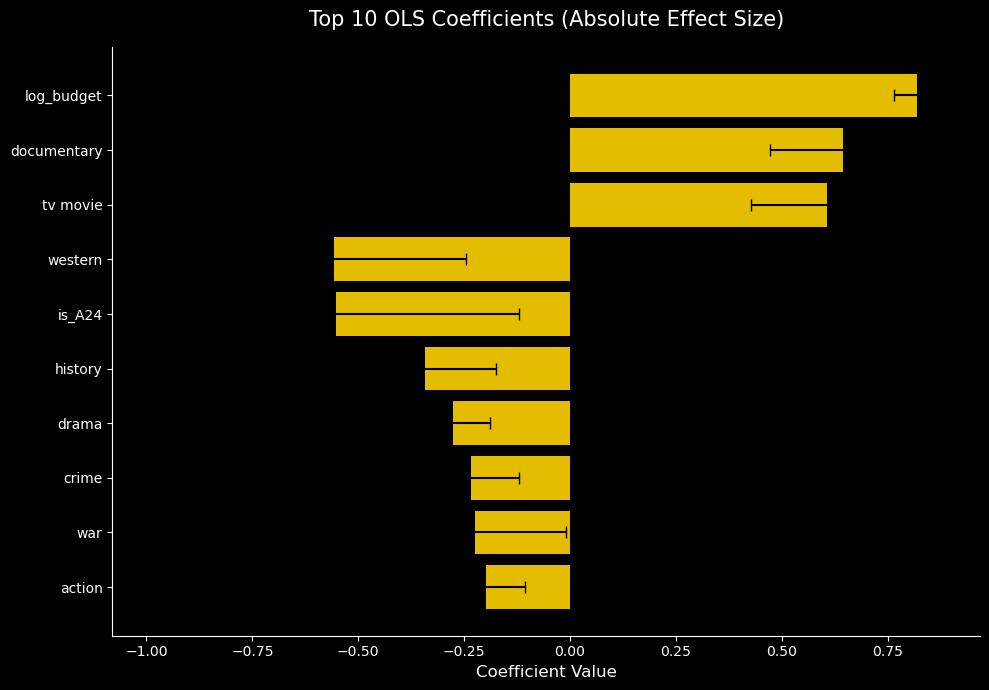

In [35]:
# --- SELECT TOP 10 COEFFICIENTS BY ABSOLUTE VALUE ---
top10 = coef_df.reindex(coef_df["coef"].abs().sort_values().tail(10).index)

# --- PLOTTING ---
plt.style.use("dark_background")
NEON_YELLOW = "#FFD300"
WHITE = "#FFFFFF"
GRAY = "#777777"

fig, ax = plt.subplots(figsize=(10, 7))

# Colors for significance
colors = [
    NEON_YELLOW if p < 0.05 else GRAY
    for p in top10["pval"]
]

ax.barh(
    top10.index,
    top10["coef"],
    xerr=[top10["coef"] - top10["lower"], top10["upper"] - top10["coef"]],
    color=colors,
    alpha=0.9,
    capsize=4
)

ax.set_title(
    "Top 10 OLS Coefficients (Absolute Effect Size)",
    fontsize=15, color=WHITE, pad=15
)

ax.set_xlabel("Coefficient Value", fontsize=12, color=WHITE)
ax.tick_params(axis="y", labelsize=10, colors=WHITE)
ax.tick_params(axis="x", colors=WHITE)

# Clean spines
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(WHITE)

plt.tight_layout()

plt.savefig("ols_coefficients_top10.png", dpi=300, transparent=True, bbox_inches="tight")
plt.show()


### Random Forest Regression

In [36]:
rf = RandomForestRegressor(
    n_estimators = 300,
    random_state = 42,
    n_jobs = -1
)

rf.fit(X_train, y_train)

# establishing predicted y
y_pred_rf = rf.predict(X_test)

# manual rmse
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5

print("Random Forest R²:", r2_score(y_test, y_pred_rf))
print("Random Forest RMSE:", rmse_rf)

Random Forest R²: 0.5464843714995901
Random Forest RMSE: 1.5029317537275908


### Feature Importances

We use feature importance from the Random Forest to see which predictors matter most for revenue.

In [37]:
# getting feature importances in descending order
importances = pd.Series(rf.feature_importances_, index = X.columns)
top_features = importances.sort_values(ascending = False).head(20)

print(top_features)

log_budget         0.615997
score              0.117955
release_year       0.100925
drama              0.016369
action             0.014795
comedy             0.013908
horror             0.013226
thriller           0.012980
science fiction    0.012223
romance            0.010616
crime              0.010148
adventure          0.009728
fantasy            0.009187
mystery            0.007028
family             0.006621
animation          0.006195
history            0.005804
war                0.004033
music              0.003933
western            0.002858
dtype: float64


## Visualizations

In [38]:
# aesthetics
plt.style.use("dark_background")
NEON_YELLOW = "#FFD300"
WHITE = "#FFFFFF"
CYAN = "#00E5FF"
MAGENTA = "#FF77FF" 

#### Distribution of Movie Budgets (A24 vs non-A24)

C:\Users\claud\AppData\Local\Temp\ipykernel_23144\4076258611.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


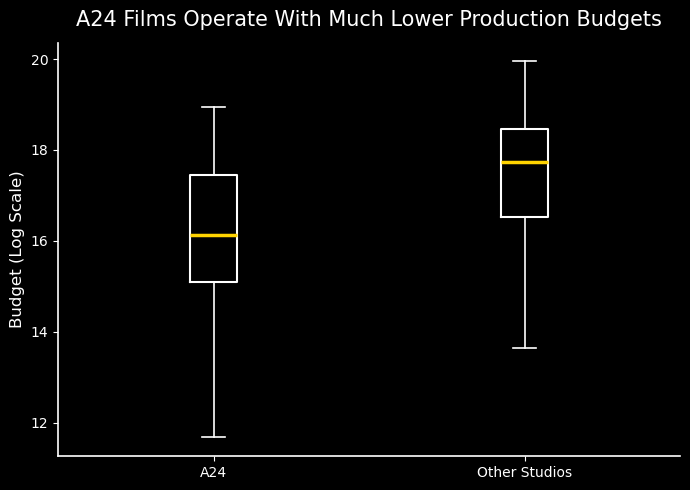

In [39]:
fig, ax = plt.subplots(figsize=(7,5))

a24_budget = movies.loc[movies['is_A24'] == 1, 'log_budget'].dropna()
other_budget = movies.loc[movies['is_A24'] == 0, 'log_budget'].dropna()

# a24 aesthetic props
boxprops     = dict(color=WHITE, linewidth=1.5)
medianprops  = dict(color=NEON_YELLOW, linewidth=2.5)
whiskerprops = dict(color=WHITE, linewidth=1.2)
capprops     = dict(color=WHITE, linewidth=1.2)

# plot
bp = ax.boxplot(
    [a24_budget, other_budget],
    labels=["A24", "Other Studios"],
    showfliers=False,
    boxprops=boxprops,
    medianprops=medianprops,
    whiskerprops=whiskerprops,
    capprops=capprops
)

# titles
ax.set_title("A24 Films Operate With Much Lower Production Budgets", 
             fontsize=15, color=WHITE, pad=12)
ax.set_ylabel("Budget (Log Scale)", fontsize=12, color=WHITE)

# axes
ax.tick_params(axis='both', colors=WHITE)

# spine cleanup
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color(WHITE)
    ax.spines[spine].set_linewidth(1.2)

plt.tight_layout()
plt.savefig("myplot1.png", dpi=300, transparent=True)
plt.show()


#### Scatter Plot: Budget vs Revenue (A24 vs non-A24)

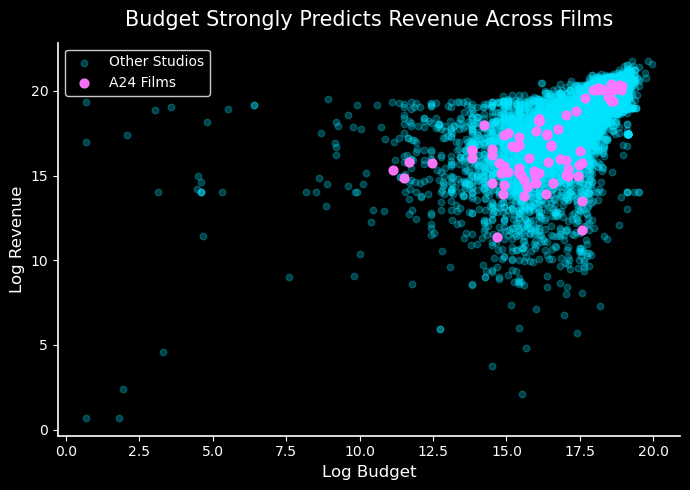

In [40]:
fig, ax = plt.subplots(figsize=(7,5))

# boolean masks
a24_mask = movies['is_A24'] == 1
other_mask = movies['is_A24'] == 0

# scatter for non-a24
ax.scatter(
    movies.loc[other_mask, 'log_budget'],
    movies.loc[other_mask, 'log_revenue'],
    alpha=0.28,
    s=22,
    color=CYAN,
    label="Other Studios"
)

# scatter for a24
ax.scatter(
    movies.loc[a24_mask, 'log_budget'],
    movies.loc[a24_mask, 'log_revenue'],
    alpha=0.95,
    s=40,
    color=MAGENTA,
    label="A24 Films"
)

# titles and labels
ax.set_title(
    "Budget Strongly Predicts Revenue Across Films",
    fontsize=15,
    color=WHITE,
    pad=12
)
ax.set_xlabel("Log Budget", fontsize=12, color=WHITE)
ax.set_ylabel("Log Revenue", fontsize=12, color=WHITE)

# legend
ax.legend(
    facecolor="black",
    edgecolor=WHITE,
    labelcolor=WHITE
)

ax.tick_params(axis='both', colors=WHITE)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(WHITE)
    ax.spines[spine].set_linewidth(1.2)

plt.tight_layout()
plt.savefig("myplot2.png", dpi=300, transparent=True)
plt.show()

#### Box Plots: Movie Ratings (A24 vs non-A24)

C:\Users\claud\AppData\Local\Temp\ipykernel_23144\3851236692.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


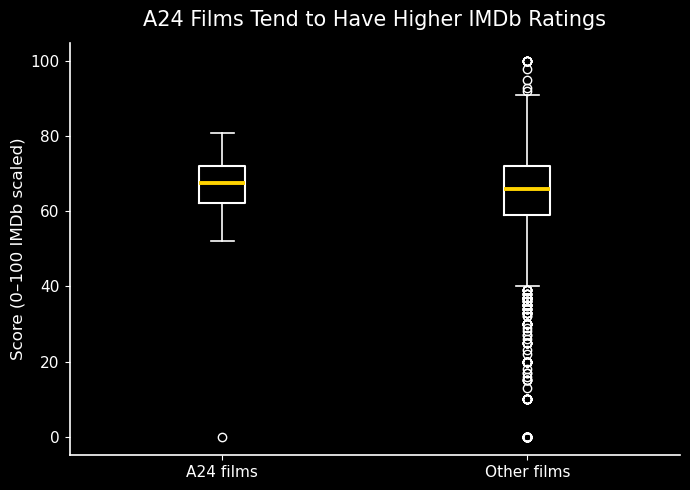

In [41]:
a24_mask = movies['is_A24'] == 1
a24_scores = movies.loc[a24_mask, 'score'].dropna()
other_scores = movies.loc[~a24_mask, 'score'].dropna()

fig, ax = plt.subplots(figsize=(7, 5))

bp = ax.boxplot(
    [a24_scores, other_scores],
    labels=["A24 films", "Other films"],
    showfliers=True,
    boxprops=dict(color=WHITE, linewidth=1.5),
    medianprops=dict(color=NEON_YELLOW, linewidth=2.8),
    whiskerprops=dict(color=WHITE, linewidth=1.2),
    capprops=dict(color=WHITE, linewidth=1.2)
)

ax.set_title("A24 Films Tend to Have Higher IMDb Ratings", fontsize=15, color=WHITE, pad=12)
ax.set_ylabel("Score (0–100 IMDb scaled)", fontsize=12, color=WHITE)

# Auto-set limits based on actual data
low, high = a24_scores.min(), other_scores.max()
ax.set_ylim(low - 5, high + 5)

ax.tick_params(axis='both', labelsize=11, colors=WHITE)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.spines['left'].set_color(WHITE)
ax.spines['bottom'].set_color(WHITE)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

plt.tight_layout()
plt.savefig("myplot3.png", dpi=300, transparent=True)
plt.show()

#### Bar Chart: Genre Composition Comparison

In [42]:
movies = movies.loc[:, ~movies.columns.duplicated()]
[col for col in movies.columns if col in genre_cols]

['action',
 'adventure',
 'animation',
 'comedy',
 'crime',
 'documentary',
 'drama',
 'family',
 'fantasy',
 'history',
 'horror',
 'music',
 'mystery',
 'nan',
 'romance',
 'science fiction',
 'thriller',
 'tv movie',
 'war',
 'western']

In [43]:
# defining genre columns
genre_cols = [
    'action','adventure','animation','comedy','crime',
    'documentary','drama','family','fantasy','history',
    'horror','music','mystery','romance',
    'science fiction','thriller','tv movie','war','western'
]

# keep only those that actually exist in the cleaned df (just in case)
genre_cols = [g for g in genre_cols if g in movies.columns]

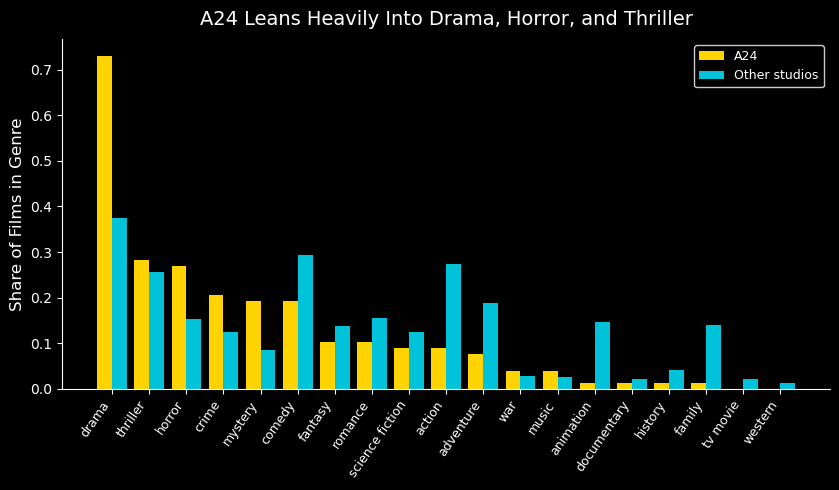

In [44]:
# mask
a24_mask = movies['is_A24'] == 1

genre_df = pd.DataFrame({
    "A24": movies.loc[a24_mask, genre_cols].mean(),
    "Other studios": movies.loc[~a24_mask, genre_cols].mean()
}).sort_values("A24", ascending=False)

x = np.arange(len(genre_df))
width = 0.4
A24_COLOR, OTHER_COLOR = NEON_YELLOW, "#00E5FF"

# bar chart settings, labels, titles...
fig, ax = plt.subplots(figsize=(8.5, 5))

ax.bar(x - width/2, genre_df["A24"], width, color=A24_COLOR, label="A24")
ax.bar(x + width/2, genre_df["Other studios"], width, color=OTHER_COLOR, alpha=0.85, label="Other studios")

ax.set_title("A24 Leans Heavily Into Drama, Horror, and Thriller", fontsize=14, color=WHITE, pad=10)
ax.set_ylabel("Share of Films in Genre", fontsize=12, color=WHITE)
ax.set_xticks(x)
ax.set_xticklabels(genre_df.index, rotation=55, ha="right", fontsize=9, color=WHITE)

ax.legend(facecolor="black", edgecolor=WHITE, labelcolor=WHITE, fontsize=9)
ax.tick_params(axis="y", colors=WHITE)

for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
for s in ["left", "bottom"]:
    ax.spines[s].set_color(WHITE)

plt.tight_layout()
plt.savefig("myplot4.png", dpi=300, transparent=True)
plt.show()

#### Feature Importance Plot (Random Forest)

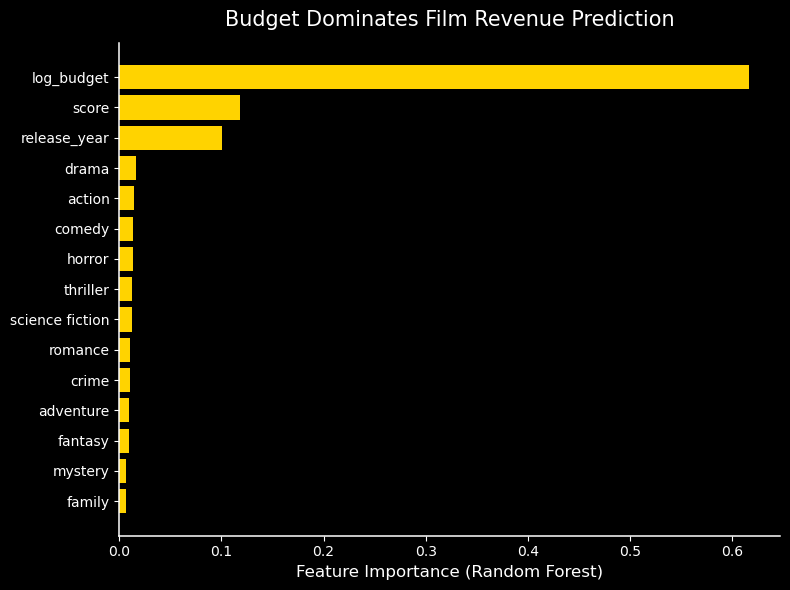

In [45]:
# new series to avoid indexing errors

importances = pd.Series(rf.feature_importances_, index=X.columns)

# sort and take top 15 features
top_feats = importances.sort_values().tail(15)

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(top_feats.index, top_feats.values, color=NEON_YELLOW)

ax.set_title(
    "Budget Dominates Film Revenue Prediction",
    fontsize=15,
    color=WHITE,
    pad=12
)

ax.set_xlabel("Feature Importance (Random Forest)", fontsize=12, color=WHITE)
ax.tick_params(axis="both", colors=WHITE, labelsize=10)

# clean A24-look spines
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(WHITE)
    ax.spines[spine].set_linewidth(1.1)

plt.tight_layout()
plt.savefig("myplot5.png", dpi=300, transparent=True)
plt.show()

## Robustness Checks

We re-estimate the Random Forest while:
- Removing `release_year`  
- Removing `score`

to verify that `log_budget` remains the dominant predictor.

### 1) 10 Fold Cross Validation

We used 10-fold cross validation to check how stable the Random Forest model is across different subsets of the data.

The model showed consistent performance across all folds, which improves confidence in the results.

#### 1.1) Linear Regression Cross Validation

In [46]:
from sklearn.model_selection import cross_val_score

cv_r2 = cross_val_score(lr, X, y, cv=10, scoring='r2')
cv_rmse = -cross_val_score(lr, X, y, cv=10, scoring='neg_root_mean_squared_error')

print("Mean R² (10-fold):", cv_r2.mean())
print("Std R²:", cv_r2.std())
print("Mean RMSE:", cv_rmse.mean())

Mean R² (10-fold): 0.36734599822161096
Std R²: 0.06597949919311934
Mean RMSE: 1.6862841570380127


#### 1.2) Random Forest Regression Cross Validation

In [47]:
cv_r2_rf = cross_val_score(rf, X, y, cv=10, scoring='r2')
cv_rmse_rf = -cross_val_score(rf, X, y, cv=10, scoring='neg_root_mean_squared_error')

print("RF Mean R² (10-fold):", cv_r2_rf.mean())
print("RF Std R²:", cv_r2_rf.std())
print("RF Mean RMSE:", cv_rmse_rf.mean())

RF Mean R² (10-fold): 0.5255793947527573
RF Std R²: 0.06835863480554197
RF Mean RMSE: 1.455449551526176


### 2) Trying other train-test splits

We tested several train–test splits to confirm that our findings were not dependent on a single split.

Model performance remained similar across all splits, showing strong stability.

In [48]:
splits = [0.2, 0.3, 0.15, 0.1]

for s in splits:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=s, random_state=42)
    
    lr.fit(X_train, y_train)
    rf.fit(X_train, y_train)
    
    y_pred_lr = lr.predict(X_test)
    y_pred_rf = rf.predict(X_test)
    
    mse_lr = mean_squared_error(y_test, y_pred_lr)
    mse_rf = mean_squared_error(y_test, y_pred_rf)

    print(f"\nTest size: {s}")
    print("LR R²:", r2_score(y_test, y_pred_lr))
    print("RF R²:", r2_score(y_test, y_pred_rf))


Test size: 0.2
LR R²: 0.42257822527745204
RF R²: 0.5464843714995901

Test size: 0.3
LR R²: 0.4060217636852561
RF R²: 0.5511643360062102

Test size: 0.15
LR R²: 0.40197228349183955
RF R²: 0.5373277606575169

Test size: 0.1
LR R²: 0.4202342390908581
RF R²: 0.5371090095331471


### 3) Removing variables

We removed predictors such as release_year and score to test whether the model depended heavily on individual variables.

Budget remained the strongest predictor, and the overall insights stayed consistent.

#### 3.1) Removing "release_year"

In [49]:
X_no_year = model_df.drop(['log_revenue', 'release_year'], axis=1)

rf.fit(X_no_year, y)
importances_no_year = pd.Series(rf.feature_importances_, index=X_no_year.columns)
importances_no_year.sort_values(ascending=False).head(10)

log_budget         0.666067
score              0.137234
action             0.017789
drama              0.017765
thriller           0.016521
comedy             0.015937
horror             0.014895
science fiction    0.013904
romance            0.013290
crime              0.012995
dtype: float64

#### 3.2) Removing "score"

In [50]:
X_no_score = model_df.drop(['log_revenue', 'score'], axis=1)

rf.fit(X_no_score, y)
importances_no_score = pd.Series(rf.feature_importances_, index=X_no_score.columns)
importances_no_score.sort_values(ascending=False).head(10)

log_budget         0.669722
release_year       0.126937
drama              0.019253
thriller           0.017487
action             0.017270
comedy             0.017263
horror             0.016659
science fiction    0.013677
romance            0.013657
crime              0.013513
dtype: float64

## Summary of Modeling Results

- Budget is the strongest predictor of box office performance in all models.  
- A24 films do not outperform expectations once budget, ratings, year, and genre are controlled for.  
- Random Forest improves predictive performance over linear regression and confirms the same feature ranking.  
